In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
import numpy as np
from datetime import datetime

In [3]:
DATA_PATH = "/Users/sahil/Developer/Quantitative Finance/aakash/data/futures"
RESULTS_PATH = "/Users/sahil/Developer/Quantitative Finance/aakash/results"

HOLD_DAYS = [3,7,10]
STOP_LOSS_PCT = [0.03, 0.05, 0.1]

### Download data from Yfinance

In [90]:
def download_data(instrument: str = "CL=F"):
    df = yf.download(instrument, interval="5m", period="60d")
    df.columns = df.columns.droplevel(1) # drop the ticker level since this is only one instrument

    os.makedirs(DATA_PATH, exist_ok=True)
    df.to_csv(f'{DATA_PATH}/crude_oil_futures.csv')
    print(f'Stored data at "{DATA_PATH}"')

### Load Data

In [4]:
def load_data(data_path=DATA_PATH, filename='crude_oil_futures.csv') -> pd.DataFrame:
    df = pd.read_csv(f"{DATA_PATH}/crude_oil_futures.csv")
    df['Datetime'] = pd.to_datetime(df.Datetime)
    df = df.set_index('Datetime')
    return df


### Signal Generation

In [5]:
# masks: 'ratio', 'zscore', or 'rvol'

def get_signals(og_df: pd.DataFrame, mask: str, rolling_window:int=375, volume_threshold:float=3.0 ) -> pd.DataFrame:
    df = og_df.copy()
    # time columns — add these first
    df['date'] = df.index.date
    df['time'] = df.index.time

    # volume metrics
    df['vol_sma'] = df['Volume'].rolling(rolling_window).mean()
    df['vol_std'] = df['Volume'].rolling(rolling_window).std()

    # ratio
    df['vol_ratio'] = df['Volume'] / df['vol_sma']
    
    # zscore
    df['vol_zscore'] = (df['Volume'] - df['vol_sma']) / df['vol_std']

    # rvol 
    today = df['date'].iloc[-1]
    hist = df[df['date'] != today]
    last_20_days = sorted(hist['date'].unique())[-20:]
    hist = hist[hist['date'].isin(last_20_days)]
    time_avg = hist.groupby('time')['Volume'].mean()
    df['rvol'] = df['Volume'] / df['time'].map(time_avg)

    # direction
    df['direction'] = np.sign(df['Close'] - df['Open'])

    # masks
    masks = {
        'ratio':  df['vol_ratio'] > volume_threshold,
        'zscore': df['vol_zscore'] > volume_threshold,
        'rvol':   df['rvol'] > volume_threshold,
    }

    # signal
    df['signal'] = 0
    selected_mask = masks[mask]
    df.loc[selected_mask, 'signal'] = df.loc[selected_mask, 'direction']

    return df

In [6]:
def analyze_spikes(df: pd.DataFrame, mask: str, combo: str)->dict:
    stats = {}
    
    spikes = df[df['signal'] != 0].copy()
    normal = df[df['signal'] == 0].copy()
    
    # meta
    stats['type']           = mask
    stats['combo']          = combo
    
    # frequency
    stats['total_candles']  = len(df)
    stats['total_spikes']   = len(spikes)
    stats['spike_rate_pct'] = len(spikes) / len(df) * 100
    stats['long_spikes']    = (df['signal'] == 1).sum()
    stats['short_spikes']   = (df['signal'] == -1).sum()
    stats['long_pct']       = stats['long_spikes'] / stats['total_spikes'] * 100
    stats['short_pct']      = stats['short_spikes'] / stats['total_spikes'] * 100

    # volume
    stats['avg_spike_vol']  = spikes['Volume'].mean()
    stats['avg_normal_vol'] = normal['Volume'].mean()
    stats['avg_rvol']       = spikes['rvol'].mean()

    # time of day
    df['hour']              = df.index.hour
    stats['spike_by_hour']  = (df[df['signal'] != 0]
                                .groupby('hour')['signal']
                                .count()
                                .sort_values(ascending=False)
                                .to_dict())

    # day of week
    df['dow']               = df.index.day_name()
    stats['spike_by_day']   = (df[df['signal'] != 0]
                                .groupby('dow')['signal']
                                .count()
                                .sort_values(ascending=False)
                                .to_dict())

    # consecutive spikes
    df['is_spike']          = (df['signal'] != 0).astype(int)
    df['spike_group']       = (df['is_spike'] != df['is_spike'].shift()).cumsum()
    consecutive             = df[df['is_spike'] == 1].groupby('spike_group').size()
    stats['consecutive']    = consecutive.value_counts().to_dict()
    stats['max_consecutive']= consecutive.max()

    return stats

In [61]:
# Look at only the strongest spikes
result = (df[df['signal'] != 0][['Open', 'Close', 'Volume', 'vol_ratio', 'vol_zscore','rvol','signal']])

result.to_csv(f"{DATA_PATH}/vol_surge.csv")

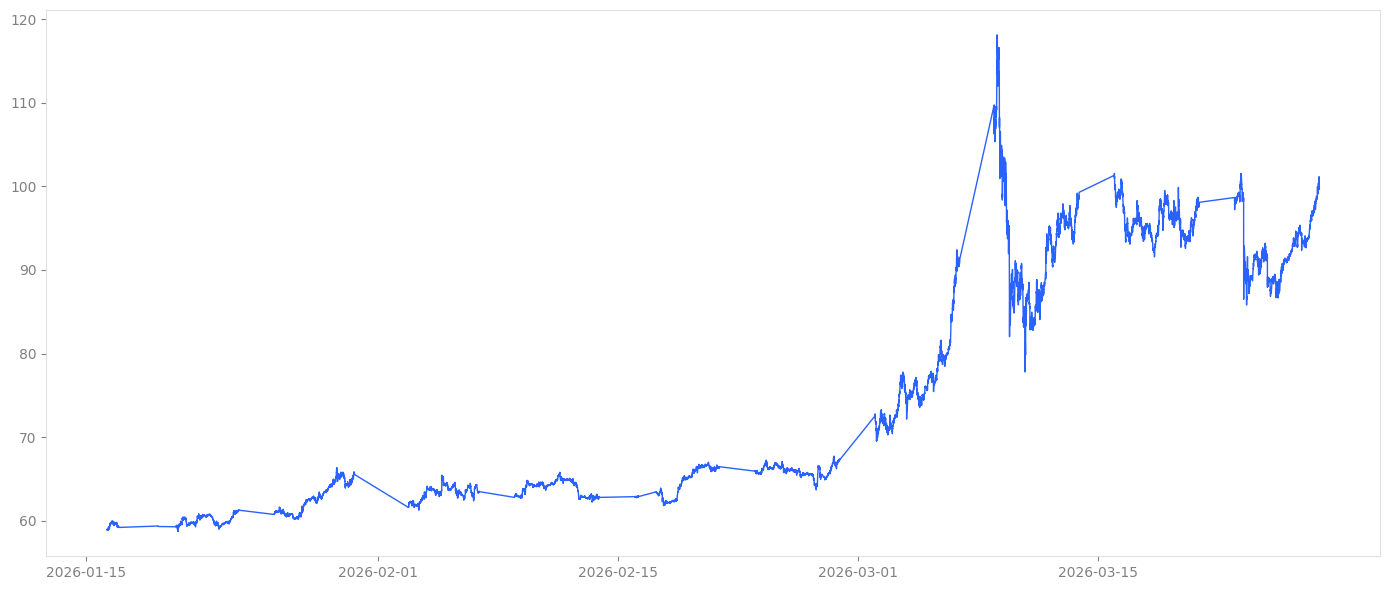

In [138]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Price
ax1.plot(df.index, df['Close'], color='#2962ff', linewidth=1)
ax1.tick_params(colors='gray')
ax1.spines[:].set_color('#e0e0e0')

# Signal bars
ax2 = ax1.twinx()
ax2.bar(df.index, df['signal'], width=5/(60*24), color='orange', alpha=0.5)
ax2.set_yticks([])
ax2.spines[:].set_visible(False)

plt.tight_layout()
plt.show()


### Backtest

In [7]:
def backtest(og_df: pd.DataFrame, stop_loss_pct: float=0.05, hold_days:int=7) -> pd.DataFrame:
    df = og_df.copy()
    signal_candles = df[df['signal'] != 0].copy()

    results = []

    for idx, row in signal_candles.iterrows():
        entry_price = row['Close']
        entry_time = idx
        direction = row['signal']  # +1 long, -1 short

        # stop loss price
        stop_price = entry_price * (1 - stop_loss_pct * direction)
        # long: stop = entry * 0.98
        # short: stop = entry * 1.02

        # get future candles within 7 days
        exit_time = entry_time + pd.Timedelta(days=hold_days)
        future_window = df[(df.index > entry_time) & (df.index <= exit_time)]

        if len(future_window) == 0:
            continue

        # check candle by candle if stop is hit
        stopped_out = False
        for candle_idx, candle in future_window.iterrows():
            if direction == 1 and candle['Low'] <= stop_price:
                exit_price = stop_price
                exit_reason = 'STOP'
                stopped_out = True
                break
            elif direction == -1 and candle['High'] >= stop_price:
                exit_price = stop_price
                exit_reason = 'STOP'
                stopped_out = True
                break

        if not stopped_out:
            exit_price = future_window['Close'].iloc[-1]
            exit_reason = 'TIME'

        pnl = direction * (exit_price - entry_price)
        pnl_pct = direction * (exit_price - entry_price) / entry_price * 100

        results.append({
            'entry_time': entry_time,
            'exit_time': candle_idx if stopped_out else future_window.index[-1],
            'direction': 'LONG' if direction == 1 else 'SHORT',
            'entry_price': entry_price,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'pnl': pnl,
            'pnl_pct': pnl_pct,
        })

    results_df = pd.DataFrame(results)

    # metrics
    stopped = results_df['exit_reason'] == 'STOP'
    print(f"Total signals:    {len(results_df)}")
    print(f"Stopped out:      {stopped.sum()} ({100*stopped.mean():.1f}%)")
    print(f"Time exit:        {(~stopped).sum()} ({100*(~stopped).mean():.1f}%)")
    print(f"Win rate:         {(results_df['pnl'] > 0).mean()*100:.1f}%")
    print(f"Avg PnL %:        {results_df['pnl_pct'].mean():.2f}%")
    print(f"Total PnL:        {results_df['pnl'].sum():.2f}")
    print(f"Best trade:       {results_df['pnl'].max():.2f}")
    print(f"Worst trade:      {results_df['pnl'].min():.2f}")

    return results_df

### Main

In [96]:
# download data
download_data("CL=F")

[*********************100%***********************]  1 of 1 completed

Stored data at "/Users/sahil/Developer/Quantitative Finance/aakash/data/futures"


In [8]:
# load df from file
df = load_data(DATA_PATH, 'crude_oil_futures.csv')

In [10]:
# generate signals

# defined config
rolling_window = 375
volume_threshold = 3.0

# generate signals
ratio_signal = get_signals(og_df=df, mask="ratio", rolling_window=rolling_window, volume_threshold=volume_threshold)
rvol_signal = get_signals(og_df=df, mask="rvol", rolling_window=rolling_window, volume_threshold=volume_threshold)
zscore_signal = get_signals(og_df=df, mask="zscore", rolling_window=rolling_window, volume_threshold=volume_threshold)

# save 
signals_path = f"{RESULTS_PATH}/signals"
os.makedirs(signals_path, exist_ok=True)

ratio_signal.to_csv(f'{signals_path}/ratio_signals_HOLD_{rolling_window}_THRESH_{volume_threshold}.csv')
rvol_signal.to_csv(f'{signals_path}/rvol_signals_HOLD_{rolling_window}_THRESH_{volume_threshold}.csv')
zscore_signal.to_csv(f'{signals_path}/zscore_signals_HOLD_{rolling_window}_THRESH_{volume_threshold}.csv')

In [11]:
# spike analysis

analysis_path = f"{RESULTS_PATH}/spike_stats"
os.makedirs(analysis_path, exist_ok=True)

spike_stats = []

spike_stats.append(analyze_spikes(ratio_signal, "ratio", f"WINDOW_{rolling_window}_THRESH_{volume_threshold}"))
spike_stats.append(analyze_spikes(rvol_signal, "rvol", f"WINDOW_{rolling_window}_THRESH_{volume_threshold}"))
spike_stats.append(analyze_spikes(zscore_signal, "zscore", f"WINDOW_{rolling_window}_THRESH_{volume_threshold}"))

spike_stats_df = pd.DataFrame(spike_stats)

now = datetime.now()
stamp = now.strftime("%Y-%m-%d %H:%M")

spike_stats_df.to_csv(f"{analysis_path}/{stamp}_stats.csv")

In [12]:
# filter non signals
ratio_signal = ratio_signal[ratio_signal['signal'] != 0]
rvol_signal = rvol_signal[rvol_signal['signal'] != 0]
zscore_signal = zscore_signal[zscore_signal['signal'] != 0]

In [13]:
def get_results(df: pd.DataFrame, name: str, combo: str) -> dict:
    
    result = {}

    result["indicator"]    = name
    result["combo"]        = combo
    result["total_trades"] = len(df)
    result["win_trades"]   = (df['pnl'] > 0).sum()
    result["loss_trades"]  = (df['pnl'] <= 0).sum()
    result["win_rate %"]   = result['win_trades'] / result['total_trades']
    result["avg_pnl %"]    = df['pnl_pct'].mean()
    result["total_pnl $"]  = df['pnl'].sum()
    result["stop_rate"]    = (df['exit_reason'] == 'STOP').mean()
    return result

In [14]:
results_list = []

# grid search 


for holding_days in HOLD_DAYS:
    for stop_loss in STOP_LOSS_PCT:
        
        combo = f"HOLD_{holding_days}_SL_{stop_loss}"
        
        trades_path = f"{RESULTS_PATH}/trades"
        os.makedirs(trades_path, exist_ok=True)

        print("\n"+"="*10+" Using Ratio " + "="*10)

        result = backtest(og_df=ratio_signal, stop_loss_pct=stop_loss, hold_days=holding_days)

        results_list.append(get_results(result, "ratio", combo))

        now = datetime.now()
        stamp = now.strftime("%Y-%m-%d %H:%M")

        result.to_csv(f'{trades_path}/{stamp}_ratio_trades_{combo}.csv')


        print("\n"+"="*10+" Using RVOL " + "="*10)

        result = backtest(og_df=rvol_signal, stop_loss_pct=stop_loss, hold_days=holding_days)

        results_list.append(get_results(result, "rvol", combo))

        now = datetime.now()
        stamp = now.strftime("%Y-%m-%d %H:%M")

        result.to_csv(f'{trades_path}/{stamp}_rvol_trades_{combo}.csv')



        print("\n"+"="*10+" Using ZScore " + "="*10)

        result = backtest(og_df=zscore_signal, stop_loss_pct=stop_loss, hold_days=holding_days)

        results_list.append(get_results(result, "zscore", combo))

        now = datetime.now()
        stamp = now.strftime("%Y-%m-%d %H:%M")

        result.to_csv(f'{trades_path}/{stamp}_zscore_trades_{combo}.csv')    


========== Using Ratio ==========
Total signals:    639
Stopped out:      290 (45.4%)
Time exit:        349 (54.6%)
Win rate:         36.6%
Avg PnL %:        0.08%
Total PnL:        25.51
Best trade:       19.25
Worst trade:      -3.09

========== Using RVOL ==========
Total signals:    306
Stopped out:      201 (65.7%)
Time exit:        105 (34.3%)
Win rate:         24.5%
Avg PnL %:        0.33%
Total PnL:        95.64
Best trade:       22.36
Worst trade:      -3.54

========== Using ZScore ==========
Total signals:    216
Stopped out:      99 (45.8%)
Time exit:        117 (54.2%)
Win rate:         37.0%
Avg PnL %:        0.25%
Total PnL:        39.54
Best trade:       19.25
Worst trade:      -3.09

========== Using Ratio ==========
Total signals:    639
Stopped out:      169 (26.4%)
Time exit:        470 (73.6%)
Win rate:         42.4%
Avg PnL %:        -0.04%
Total PnL:        -18.27
Best trade:       19.25
Worst trade:      -5.15

========== Using RVOL ==========
Total signals:   

In [15]:

now = datetime.now()
stamp = now.strftime("%Y-%m-%d %H:%M")

results_list_df = pd.DataFrame(results_list)
results_list_df.to_csv(f"{RESULTS_PATH}/{stamp}_results.csv")

print(f'results saved to "{RESULTS_PATH}/{stamp}_results.csv"')

results saved to "/Users/sahil/Developer/Quantitative Finance/aakash/results/2026-03-31 02:48_results.csv"
